In [ ]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
columns = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']

# Read the data in the CSV file using pandas
iris = pd.read_csv(r"..\data\iris\iris.data", sep=",", names=columns)

# Check shape
print(iris.shape)
print(iris["class"].value_counts())

(150, 5)
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Pre-Processing

1. Check for misisng values and either drop or impute (not needed as no missing values)
2. Categorical -> Numerical
3. Standardise / Normalise



In [ ]:
# Prints concise summary including count of non-null entries and data type of each column
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal length in cm  150 non-null    float64
 1   sepal width in cm   150 non-null    float64
 2   petal length in cm  150 non-null    float64
 3   petal width in cm   150 non-null    float64
 4   class               150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# check for missing values
print("\nNumber of total missing values =",iris.isnull().sum().sum())


Number of total missing values = 0


In [ ]:
# label encoding of class with
# Iris-setosa      = 0
# Iris-versicolor  = 1
# Iris-virginica   = 2
iris["class"] = LabelEncoder().fit_transform(iris["class"])

print(iris.head())
# print(iris.tail())

   sepal length in cm  sepal width in cm  petal length in cm  \
0                 5.1                3.5                 1.4   
1                 4.9                3.0                 1.4   
2                 4.7                3.2                 1.3   
3                 4.6                3.1                 1.5   
4                 5.0                3.6                 1.4   

   petal width in cm  class  
0                0.2      0  
1                0.2      0  
2                0.2      0  
3                0.2      0  
4                0.2      0  


                    min  max      mean       std
sepal length in cm  4.3  7.9  5.843333  0.828066
sepal width in cm   2.0  4.4  3.054000  0.433594
petal length in cm  1.0  6.9  3.758667  1.764420
petal width in cm   0.1  2.5  1.198667  0.763161
class               0.0  2.0  1.000000  0.819232


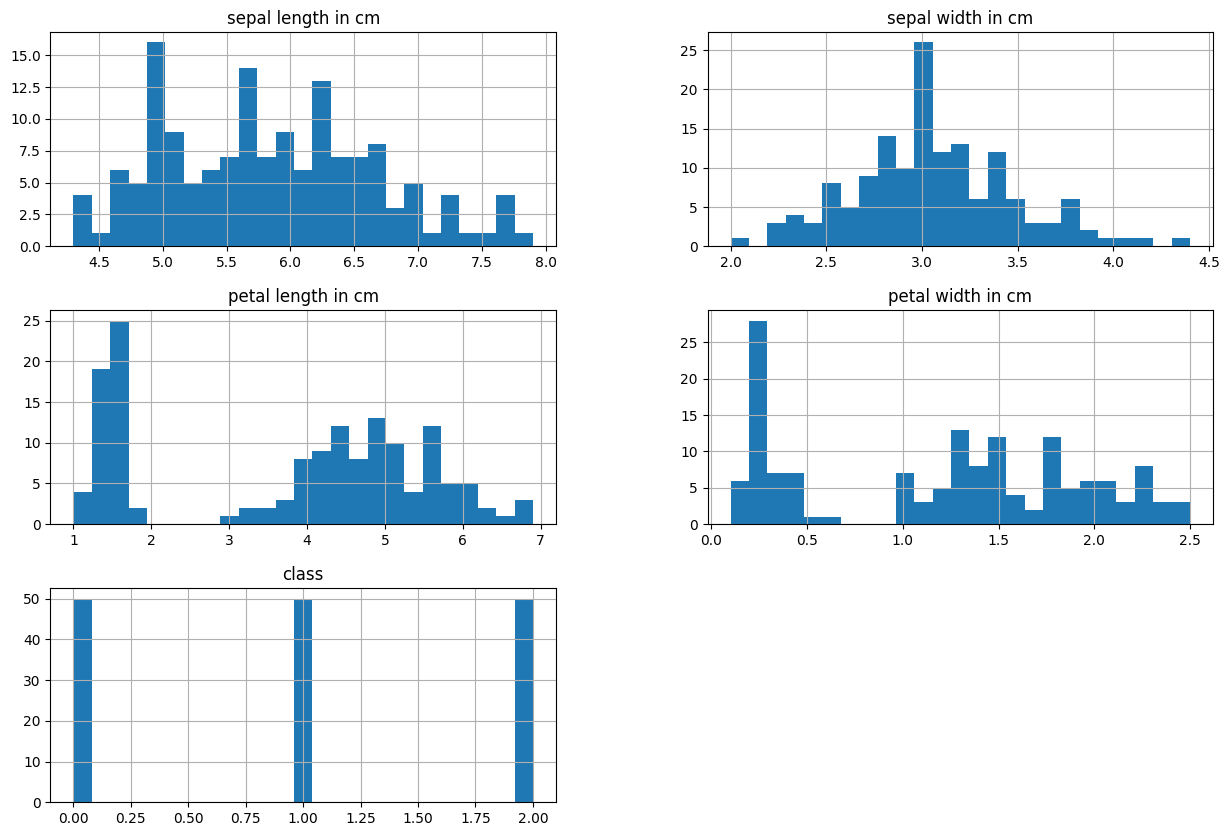

In [ ]:
# check ranges of each attribute
print(iris.describe().T[["min", "max", "mean", "std"]])

iris.hist(bins=25, figsize=(15,10))
plt.show()


In [ ]:
# standardise all columns except categorical

num_features = iris.columns
num_features = num_features.drop('class')

iris[num_features] = StandardScaler().fit_transform(iris[num_features])

print(iris.describe().T[["min", "max", "mean", "std"]])


                         min       max          mean       std
sepal length in cm -1.870024  2.492019 -4.736952e-16  1.003350
sepal width in cm  -2.438987  3.114684 -6.631732e-16  1.003350
petal length in cm -1.568735  1.786341  3.315866e-16  1.003350
petal width in cm  -1.444450  1.710902 -2.842171e-16  1.003350
class               0.000000  2.000000  1.000000e+00  0.819232


In [ ]:
print(iris)

     sepal length in cm  sepal width in cm  petal length in cm  \
0             -0.900681           1.032057           -1.341272   
1             -1.143017          -0.124958           -1.341272   
2             -1.385353           0.337848           -1.398138   
3             -1.506521           0.106445           -1.284407   
4             -1.021849           1.263460           -1.341272   
..                  ...                ...                 ...   
145            1.038005          -0.124958            0.819624   
146            0.553333          -1.281972            0.705893   
147            0.795669          -0.124958            0.819624   
148            0.432165           0.800654            0.933356   
149            0.068662          -0.124958            0.762759   

     petal width in cm  class  
0            -1.312977      0  
1            -1.312977      0  
2            -1.312977      0  
3            -1.312977      0  
4            -1.312977      0  
..             

In [ ]:
# data split
X = iris.drop('class', axis=1)
y = iris['class']

In [ ]:
# function to plot metrics vs changing hyperparameters

def plot_metrics(df, x, title, log_scale=False):
    plt.figure(figsize=(8,5))

    # Always convert x column to string to handle mixed types (e.g., gamma)
    x_vals = df[x].astype(str)

    plt.plot(x_vals, df["Mean Accuracy"], marker='o', label="Accuracy")
    plt.plot(x_vals, df["Mean F1 Score"], marker='o', label="F1 Score")
    plt.plot(x_vals, df["Mean AUC ROC"], marker='o', label="AUC RUC")

    # Log scale only applies to true numeric x values
    if log_scale:
        # Only apply log scale if values are numeric
        try:
            numeric_vals = pd.to_numeric(df[x], errors='raise')
            plt.xscale("log")
        except:
            print("⚠ Log scale ignored: X axis contains non-numeric values.")

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid(True)
    plt.show()


# Logistic Regression


In [ ]:
# defualt values for LogisticRegression in scikit

# class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1,
# class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)

In [ ]:
# defining all hyperparameter values
penalties = ['none', 'l2', 'l1', 'elasticnet']
solvers = ['liblinear', 'lbfgs', 'saga']
reg_strengths = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [ ]:
lg_solver = []
for solver in solvers:
    model = LogisticRegression(solver = solver, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    lg_solver.append({'Penalty': 'l2',
                'Solver': solver,
                'Regularisation Strength': 1.0,
                'L1 Ratio': 'None',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

lg_penalty = []
for penalty in penalties:
    if penalty == 'elasticnet':
        model = LogisticRegression(penalty = penalty, solver='saga', l1_ratio=0.5, max_iter=10000)
    elif penalty == 'none':
        model = LogisticRegression(penalty = None, solver='saga', max_iter=10000)
    else:
        model = LogisticRegression(penalty = penalty, solver='saga', max_iter=10000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    lg_penalty.append({'Penalty': penalty,
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': 0.5 if penalty == 'elasticnet' else 'None',
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score': scores['test_f1_macro'].mean(),
              'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

lg_C = []
for reg_strength in reg_strengths:
    model = LogisticRegression(C=reg_strength, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    lg_C.append({'Penalty': 'l2',
              'Solver': 'lbfgs',
              'Regularisation Strength': reg_strength,
              'L1 Ratio': 'None',
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score': scores['test_f1_macro'].mean(),
              'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

lg_l1ratio = []
for L1_ratio in L1_ratios:
    model = LogisticRegression(penalty = 'elasticnet',solver='saga',l1_ratio=L1_ratio, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    lg_l1ratio.append({'Penalty': 'elasticnet',
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': L1_ratio,
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score': scores['test_f1_macro'].mean(),
              'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

In [ ]:
df_lg_solver = pd.DataFrame(lg_solver)
df_lg_penalty = pd.DataFrame(lg_penalty)
df_lg_C = pd.DataFrame(lg_C)
df_lg_l1ratio = pd.DataFrame(lg_l1ratio)

display(df_lg_solver)
print("\n\n")
display(df_lg_penalty)
print("\n\n")
display(df_lg_C)
print("\n\n")
display(df_lg_l1ratio)
print("\n\n")

lg_hp_solv_acc = (df_lg_solver['Mean Accuracy'].var())
lg_hp_pnlt_acc = (df_lg_penalty['Mean Accuracy'].var())
lg_hp_regs_acc = (df_lg_C['Mean Accuracy'].var())
lg_hp_l1ra_acc = (df_lg_l1ratio['Mean Accuracy'].var())

lg_hp_solv_f1 = (df_lg_solver['Mean F1 Score'].var())
lg_hp_pnlt_f1 = (df_lg_penalty['Mean F1 Score'].var())
lg_hp_regs_f1 = (df_lg_C['Mean F1 Score'].var())
lg_hp_l1ra_f1 = (df_lg_l1ratio['Mean F1 Score'].var())

lg_hp_solv_auc = (df_lg_solver['Mean AUC ROC'].var())
lg_hp_pnlt_auc = (df_lg_penalty['Mean AUC ROC'].var())
lg_hp_regs_auc = (df_lg_C['Mean AUC ROC'].var())
lg_hp_l1ra_auc = (df_lg_l1ratio['Mean AUC ROC'].var())

print("Solver (Accuracy): " + str(lg_hp_solv_acc))
print("Penalty (Accuracy): " + str(lg_hp_pnlt_acc))
print("Reg Strength (Accuracy): " + str(lg_hp_regs_acc))
print("L1 Ratio (Accuracy): " + str(lg_hp_l1ra_acc))
print("\n")
print("Solver (F1 Score): " + str(lg_hp_solv_f1))
print("Penalty (F1 Score): " + str(lg_hp_pnlt_f1))
print("Reg Strength (F1 Score): " + str(lg_hp_regs_f1))
print("L1 Ratio (F1 Score): " + str(lg_hp_l1ra_f1))
print("\n")
print("Solver (AUC): " + str(lg_hp_solv_auc))
print("Penalty (AUC): " + str(lg_hp_pnlt_auc))
print("Reg Strength (AUC): " + str(lg_hp_regs_auc))
print("L1 Ratio (AUC): " + str(lg_hp_l1ra_auc))

,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,liblinear,1.0,None,0.906667,0.903796,0.972667
1,l2,lbfgs,1.0,None,0.960000,0.959596,0.997333
2,l2,saga,1.0,None,0.960000,0.959596,0.997333


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,none,saga,1.0,None,0.98,0.979933,0.998667
1,l2,saga,1.0,None,0.96,0.959596,0.997333
2,l1,saga,1.0,None,0.96,0.959596,0.997333
3,elasticnet,saga,1.0,0.5,0.96,0.959596,0.997333


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,lbfgs,0.001,None,0.82,0.796525,0.906667
1,l2,lbfgs,0.010,None,0.88,0.871916,0.961333
2,l2,lbfgs,0.100,None,0.92,0.916709,0.980667
3,l2,lbfgs,1.000,None,0.96,0.959596,0.997333
4,l2,lbfgs,10.000,None,0.98,0.979933,0.998667
5,l2,lbfgs,100.000,None,0.98,0.979933,0.998667
6,l2,lbfgs,1000.000,None,0.98,0.979933,0.997333


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,elasticnet,saga,1.0,0.1,0.960000,0.959596,0.997333
1,elasticnet,saga,1.0,0.2,0.960000,0.959596,0.997333
2,elasticnet,saga,1.0,0.3,0.960000,0.959596,0.997333
3,elasticnet,saga,1.0,0.4,0.960000,0.959596,0.997333
4,elasticnet,saga,1.0,0.5,0.960000,0.959596,0.997333
5,elasticnet,saga,1.0,0.6,0.960000,0.959596,0.997333
6,elasticnet,saga,1.0,0.7,0.966667,0.966465,0.997333
7,elasticnet,saga,1.0,0.8,0.960000,0.959596,0.997333
8,elasticnet,saga,1.0,0.9,0.960000,0.959596,0.997333





Solver (Accuracy): 0.0009481481481481564
Penalty (Accuracy): 9.999999999999907e-05
Reg Strength (Accuracy): 0.0038476190476190494
L1 Ratio (Accuracy): 4.938271604938171e-06


Solver (F1 Score): 0.001037864033805441
Penalty (F1 Score): 0.00010339534514618787
Reg Strength (F1 Score): 0.004938205706516545
L1 Ratio (F1 Score): 5.242095477785781e-06


Solver (AUC): 0.00020281481481481398
Penalty (AUC): 4.4444444444442067e-07
Reg Strength (AUC): 0.0011618412698412692
L1 Ratio (AUC): 1.3866695599588098e-32


In [ ]:
lg_summary = pd.DataFrame({
    "Hyperparameter": ["Solver", "Penalty", "C", "L1 Ratio"],
    "Var_Accuracy": [lg_hp_solv_acc, lg_hp_pnlt_acc, lg_hp_regs_acc, lg_hp_l1ra_acc],
    "Var_F1_Score": [lg_hp_solv_f1, lg_hp_pnlt_f1, lg_hp_regs_f1, lg_hp_l1ra_f1],
    "Var_AUC_ROC": [lg_hp_solv_auc, lg_hp_pnlt_auc, lg_hp_regs_auc, lg_hp_l1ra_auc]
})

display(lg_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Solver,0.000948,0.001038,2.028148e-04
1,Penalty,0.000100,0.000103,4.444444e-07
2,C,0.003848,0.004938,1.161841e-03
3,L1 Ratio,0.000005,0.000005,1.386670e-32


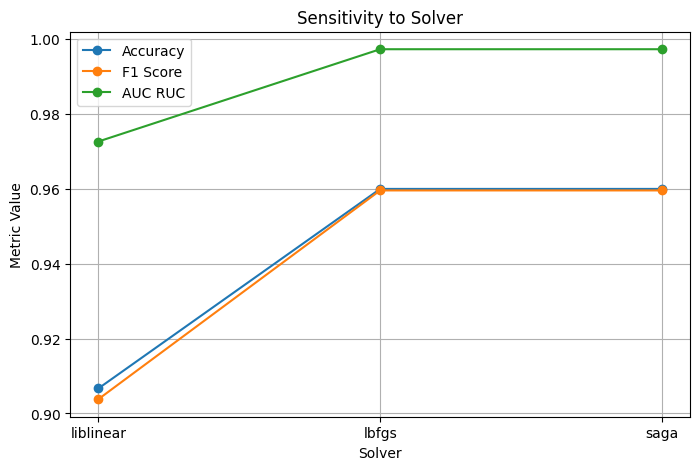

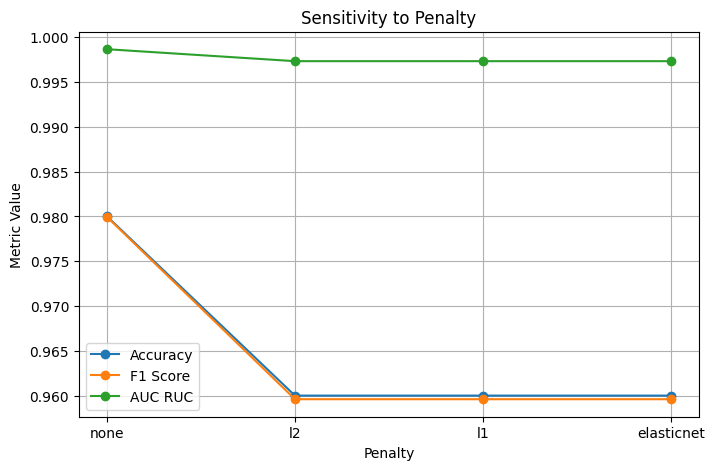

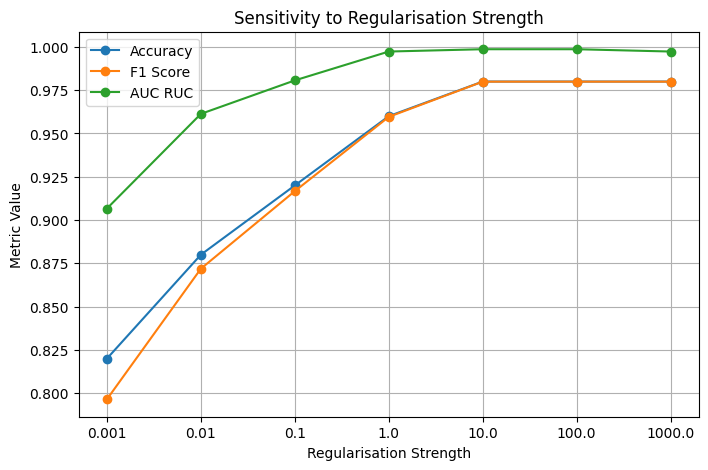

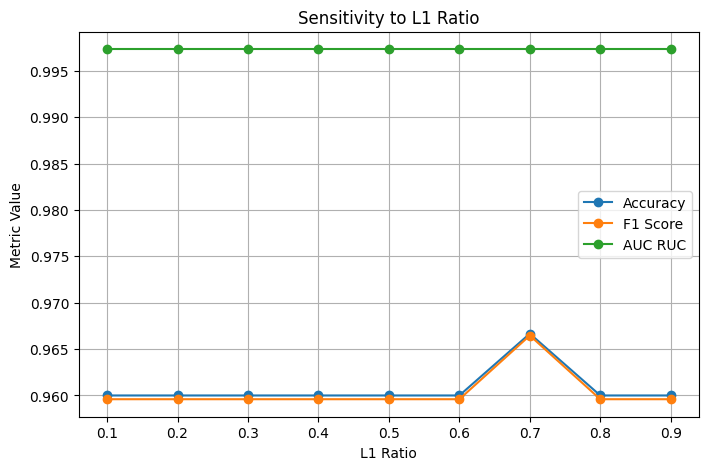

In [ ]:
plot_metrics(df_lg_solver, 'Solver', 'Sensitivity to Solver')
plot_metrics(df_lg_penalty, 'Penalty', 'Sensitivity to Penalty')
plot_metrics(df_lg_C, 'Regularisation Strength', 'Sensitivity to Regularisation Strength')
plot_metrics(df_lg_l1ratio, 'L1 Ratio', 'Sensitivity to L1 Ratio')

# K-Nearest Neighbours

In [ ]:
# defualt values for KNeighborsClassifier in scikit

# class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski',
# metric_params=None, n_jobs=None)

In [ ]:
# defining all hyperparameter values
n_neighbors = [i for i in range(1,32)]
weights = ['uniform','distance']
algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']
metric = ['euclidean', 'manhattan', 'minkowski','chebyshev','cosine']

In [ ]:
knn_kneighbours = []
for k in n_neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    knn_kneighbours.append({'N Neighbours': k,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})


knn_weightmetric = []
for w in weights:
    model = KNeighborsClassifier(weights=w)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    knn_weightmetric.append({'N Neighbours': 5,
                'Weight Metric': w,
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

knn_algorithms = []
for a in algorithms:
    model = KNeighborsClassifier(algorithm=a)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    knn_algorithms.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': a,
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})


knn_distmetric = []
for d in metric:
    model = KNeighborsClassifier(metric=d)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    knn_distmetric.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': d,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})


In [ ]:
df_knn_kneighbours = pd.DataFrame(knn_kneighbours)
df_knn_weightmetric = pd.DataFrame(knn_weightmetric)
df_knn_algorithms = pd.DataFrame(knn_algorithms)
df_knn_distmetric = pd.DataFrame(knn_distmetric)

display(df_knn_kneighbours)
print("\n\n")
display(df_knn_weightmetric)
print("\n\n")
display(df_knn_algorithms)
print("\n\n")
display(df_knn_distmetric)
print("\n\n")

knn_hp_knei_acc = (df_knn_kneighbours['Mean Accuracy'].var())
knn_hp_weig_acc = (df_knn_weightmetric['Mean Accuracy'].var())
knn_hp_algo_acc = (df_knn_algorithms['Mean Accuracy'].var())
knn_hp_dist_acc = (df_knn_distmetric['Mean Accuracy'].var())

knn_hp_knei_f1 = (df_knn_kneighbours['Mean F1 Score'].var())
knn_hp_weig_f1 = (df_knn_weightmetric['Mean F1 Score'].var())
knn_hp_algo_f1 = (df_knn_algorithms['Mean F1 Score'].var())
knn_hp_dist_f1 = (df_knn_distmetric['Mean F1 Score'].var())

knn_hp_knei_auc = (df_knn_kneighbours['Mean AUC ROC'].var())
knn_hp_weig_auc = (df_knn_weightmetric['Mean AUC ROC'].var())
knn_hp_algo_auc = (df_knn_algorithms['Mean AUC ROC'].var())
knn_hp_dist_auc = (df_knn_distmetric['Mean AUC ROC'].var())

print("K Neighbours (Accuracy): " + str(knn_hp_knei_acc))
print("Weight Metric (Accuracy): " + str(knn_hp_weig_acc))
print("Algorithm (Accuracy): " + str(knn_hp_algo_acc))
print("Distance Metric (Accuracy): " + str(knn_hp_dist_acc))
print("\n")
print("K Neighbours (F1 Score): " + str(knn_hp_knei_f1))
print("Weight Metric (F1 Score): " + str(knn_hp_weig_f1))
print("Algorithm (F1 Score): " + str(knn_hp_algo_f1))
print("Distance Metric (F1 Score): " + str(knn_hp_dist_f1))
print("\n")
print("K Neighbours (AUC): " + str(knn_hp_knei_auc))
print("Weight Metric (AUC): " + str(knn_hp_weig_auc))
print("Algorithm (AUC): " + str(knn_hp_algo_auc))
print("Distance Metric (AUC): " + str(knn_hp_dist_auc))

,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1,uniform,auto,Euclidean,0.953333,0.952441,0.965000
1,2,uniform,auto,Euclidean,0.953333,0.952441,0.965000
2,3,uniform,auto,Euclidean,0.953333,0.952441,0.977333
3,4,uniform,auto,Euclidean,0.946667,0.946128,0.986667
4,5,uniform,auto,Euclidean,0.953333,0.952576,0.996000
5,6,uniform,auto,Euclidean,0.966667,0.966465,0.996000
6,7,uniform,auto,Euclidean,0.953333,0.952997,0.997333
7,8,uniform,auto,Euclidean,0.966667,0.966330,0.996667
8,9,uniform,auto,Euclidean,0.953333,0.952997,0.996667
9,10,uniform,auto,Euclidean,0.960000,0.959596,0.996000


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.953333,0.952576,0.996000
1,5,distance,auto,Euclidean,0.953333,0.952576,0.997333


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.953333,0.952576,0.996
1,5,uniform,ball_tree,Euclidean,0.953333,0.952576,0.996
2,5,uniform,kd_tree,Euclidean,0.953333,0.952576,0.996
3,5,uniform,brute,Euclidean,0.953333,0.952576,0.996


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,euclidean,0.953333,0.952576,0.996000
1,5,uniform,auto,manhattan,0.946667,0.945707,0.995333
2,5,uniform,auto,minkowski,0.953333,0.952576,0.996000
3,5,uniform,auto,chebyshev,0.946667,0.945707,0.988333
4,5,uniform,auto,cosine,0.860000,0.852362,0.947667





K Neighbours (Accuracy): 5.448028673835104e-05
Weight Metric (Accuracy): 0.0
Algorithm (Accuracy): 0.0
Distance Metric (Accuracy): 0.001631111111111112


K Neighbours (F1 Score): 5.868709237359926e-05
Weight Metric (F1 Score): 0.0
Algorithm (F1 Score): 0.0
Distance Metric (F1 Score): 0.0018850568501386198


K Neighbours (AUC): 6.421242532855409e-05
Weight Metric (AUC): 8.888888888889891e-07
Algorithm (AUC): 0.0
Distance Metric (AUC): 0.0004382777777777763


In [ ]:
knn_summary = pd.DataFrame({
    "Hyperparameter": ["N Neighbours","Weight Metric","Algorithm","Distance Metric"],
    "Var_Accuracy": [knn_hp_knei_acc, knn_hp_weig_acc, knn_hp_algo_acc, knn_hp_dist_acc],
    "Var_F1_Macro": [knn_hp_knei_f1, knn_hp_weig_f1, knn_hp_algo_f1, knn_hp_dist_f1],
    "Var_AUC_OvR": [knn_hp_knei_auc, knn_hp_weig_auc, knn_hp_algo_auc, knn_hp_dist_auc]
})

display(knn_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Macro,Var_AUC_OvR
0,N Neighbours,0.000054,0.000059,6.421243e-05
1,Weight Metric,0.000000,0.000000,8.888889e-07
2,Algorithm,0.000000,0.000000,0.000000e+00
3,Distance Metric,0.001631,0.001885,4.382778e-04


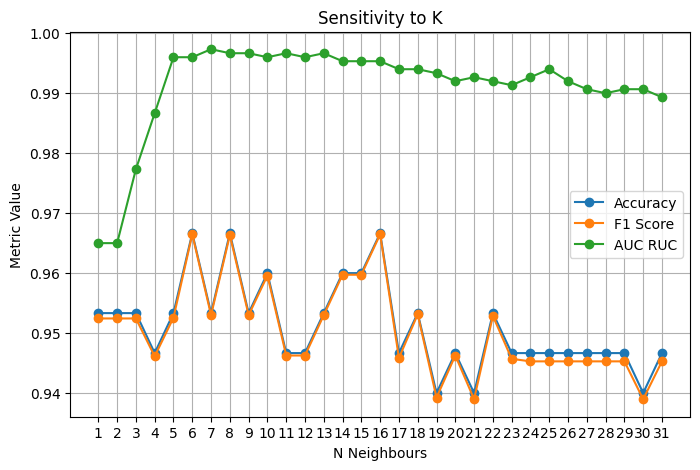

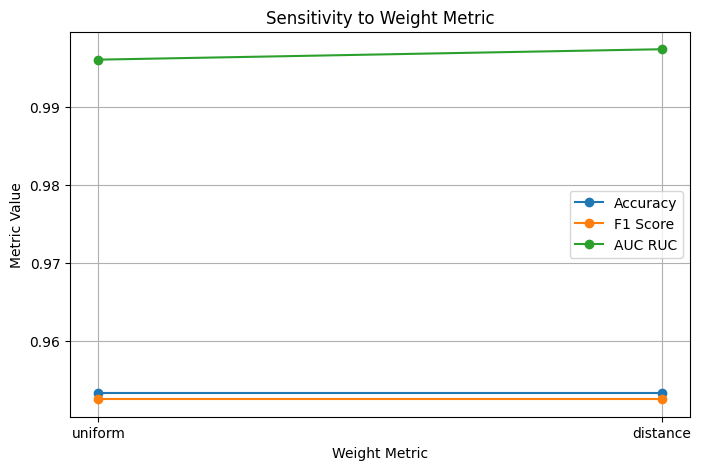

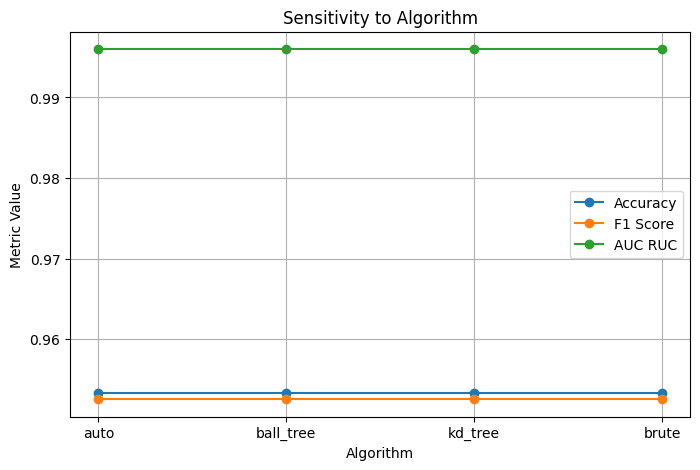

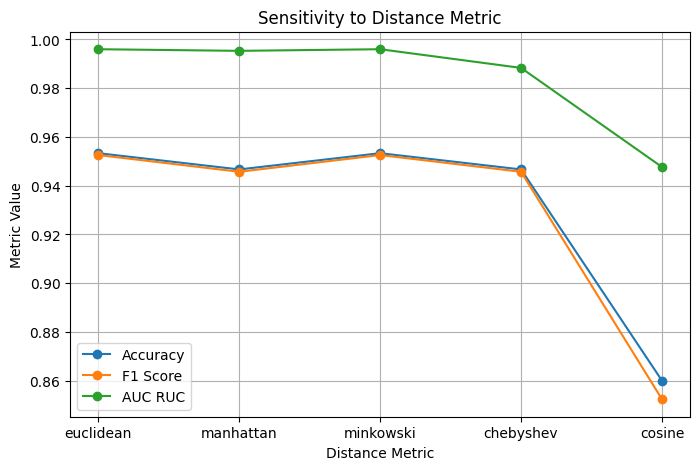

In [ ]:
plot_metrics(df_knn_kneighbours, "N Neighbours", "Sensitivity to K")
plot_metrics(df_knn_weightmetric, "Weight Metric", "Sensitivity to Weight Metric")
plot_metrics(df_knn_algorithms, "Algorithm", "Sensitivity to Algorithm")
plot_metrics(df_knn_distmetric, "Distance Metric", "Sensitivity to Distance Metric")

# Decision Tree


In [ ]:
# defualt values for DecisionTreeClassifier in scikit

# class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1,
# min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None,
# ccp_alpha=0.0, monotonic_cst=None)

In [ ]:
# defining all hyperparameter values
criteria = ['gini','entropy','log_loss']
max_depths = [None,2,3,5,10,15,20]
min_samples_splits = [2,5,10,15,20]
min_samples_leafs = [1,2,5,8,10]
max_features = [None, 'sqrt', 'log2']

In [ ]:
dt_criteria = []
for c in criteria:
    model = DecisionTreeClassifier(criterion=c)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    dt_criteria.append({'Criterion': c,
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

dt_maxdepth = []
for d in max_depths:
    model = DecisionTreeClassifier(criterion='entropy',max_depth=d)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    dt_maxdepth.append({'Criterion': 'entropy',
                'Max Depth': 'none' if d == None else d,
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

dt_minsamplesplit = []
for s in min_samples_splits:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_split=s)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    dt_minsamplesplit.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': s,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

dt_minsamplesleaf = []
for l in min_samples_leafs:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_leaf=l)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    dt_minsamplesleaf.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': l,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

dt_maxfeatures = []
for f in max_features:
    model = DecisionTreeClassifier(criterion='entropy',max_features=f)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    dt_maxfeatures.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none' if f == None else f,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})


In [ ]:
df_dt_criteria = pd.DataFrame(dt_criteria)
df_dt_maxdepth = pd.DataFrame(dt_maxdepth)
df_dt_minsamplesplit = pd.DataFrame(dt_minsamplesplit)
df_dt_minsamplesleaf = pd.DataFrame(dt_minsamplesleaf)
df_dt_maxfeatures = pd.DataFrame(dt_maxfeatures)

display(df_dt_criteria)
print("\n\n")
display(df_dt_maxdepth)
print("\n\n")
display(df_dt_minsamplesplit)
print("\n\n")
display(df_dt_minsamplesleaf)
print("\n\n")
display(df_dt_maxfeatures)
print("\n\n")

dt_hp_crit_acc = (df_dt_criteria['Mean Accuracy'].var())
dt_hp_maxd_acc = (df_dt_maxdepth['Mean Accuracy'].var())
dt_hp_split_acc = (df_dt_minsamplesplit['Mean Accuracy'].var())
dt_hp_leaf_acc = (df_dt_minsamplesleaf['Mean Accuracy'].var())
dt_hp_maxf_acc = (df_dt_maxfeatures['Mean Accuracy'].var())

dt_hp_crit_f1 = (df_dt_criteria['Mean F1 Score'].var())
dt_hp_maxd_f1 = (df_dt_maxdepth['Mean F1 Score'].var())
dt_hp_split_f1 = (df_dt_minsamplesplit['Mean F1 Score'].var())
dt_hp_leaf_f1 = (df_dt_minsamplesleaf['Mean F1 Score'].var())
dt_hp_maxf_f1 = (df_dt_maxfeatures['Mean F1 Score'].var())

dt_hp_crit_auc = (df_dt_criteria['Mean AUC ROC'].var())
dt_hp_maxd_auc = (df_dt_maxdepth['Mean AUC ROC'].var())
dt_hp_split_auc = (df_dt_minsamplesplit['Mean AUC ROC'].var())
dt_hp_leaf_auc = (df_dt_minsamplesleaf['Mean AUC ROC'].var())
dt_hp_maxf_auc = (df_dt_maxfeatures['Mean AUC ROC'].var())

print("Criteria (Accuracy) : " + str(dt_hp_crit_acc))
print("Max Depth (Accuracy) : " + str(dt_hp_maxd_acc))
print("Min Samples Split (Accuracy) : " + str(dt_hp_split_acc))
print("Min Samples Leaf (Accuracy) : " + str(dt_hp_leaf_acc))
print("Max Features (Accuracy) : " + str(dt_hp_maxf_acc))
print("\n")
print("Criteria (F1 Score) : " + str(dt_hp_crit_f1))
print("Max Depth (F1 Score) : " + str(dt_hp_maxd_f1))
print("Min Samples Split (F1 Score) : " + str(dt_hp_split_f1))
print("Min Samples Leaf (F1 Score) : " + str(dt_hp_leaf_f1))
print("Max Features (F1 Score) : " + str(dt_hp_maxf_f1))
print("\n")
print("Criteria (AUC) : " + str(dt_hp_crit_auc))
print("Max Depth (AUC) : " + str(dt_hp_maxd_auc))
print("Min Samples Split (AUC) : " + str(dt_hp_split_auc))
print("Min Samples Leaf (AUC) : " + str(dt_hp_leaf_auc))
print("Max Features (AUC) : " + str(dt_hp_maxf_auc))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,gini,none,2,1,none,0.953333,0.952997,0.965
1,entropy,none,2,1,none,0.953333,0.952997,0.965
2,log_loss,none,2,1,none,0.953333,0.952997,0.965


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.953333,0.952997,0.965
1,entropy,2,2,1,none,0.946667,0.945842,0.970
2,entropy,3,2,1,none,0.960000,0.959596,0.979
3,entropy,5,2,1,none,0.953333,0.952997,0.965
4,entropy,10,2,1,none,0.953333,0.952997,0.965
5,entropy,15,2,1,none,0.953333,0.952997,0.965
6,entropy,20,2,1,none,0.953333,0.952997,0.965


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.953333,0.952997,0.965000
1,entropy,none,5,1,none,0.960000,0.959596,0.977333
2,entropy,none,10,1,none,0.960000,0.959596,0.977333
3,entropy,none,15,1,none,0.960000,0.959596,0.977333
4,entropy,none,20,1,none,0.960000,0.959596,0.977333


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,0.953333,0.952997,0.965000
1,entropy,none,2,2,0.953333,0.952997,0.977333
2,entropy,none,2,5,0.960000,0.959310,0.974000
3,entropy,none,2,8,0.953333,0.952576,0.976000
4,entropy,none,2,10,0.953333,0.952576,0.977667


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.953333,0.952997,0.965
1,entropy,none,2,1,sqrt,0.953333,0.952441,0.965
2,entropy,none,2,1,log2,0.953333,0.952862,0.965





Criteria (Accuracy) : 1.8488927466117464e-32
Max Depth (Accuracy) : 1.4814814814814759e-05
Min Samples Split (Accuracy) : 8.888888888888709e-06
Min Samples Leaf (Accuracy) : 8.8888888888893e-06
Max Features (Accuracy) : 1.8488927466117464e-32


Criteria (F1 Score) : 0.0
Max Depth (F1 Score) : 1.5783226417345353e-05
Min Samples Split (F1 Score) : 8.71022231291593e-06
Min Samples Leaf (F1 Score) : 8.555674591028324e-06
Max Features (F1 Score) : 8.398613898047615e-08


Criteria (AUC) : 1.8488927466117464e-32
Max Depth (AUC) : 2.823809523809436e-05
Min Samples Split (AUC) : 3.04222222222221e-05
Min Samples Leaf (AUC) : 2.7388888888888628e-05
Max Features (AUC) : 1.8488927466117464e-32


In [ ]:
dt_summary = pd.DataFrame({
    "Hyperparameter": ["Criterion", "Max Depth", "Min Samples Split", "Min Samples Leaf", "Max Features"],
    "Var_Accuracy": [dt_hp_crit_acc, dt_hp_maxd_acc, dt_hp_split_acc, dt_hp_leaf_acc, dt_hp_maxf_acc],
    "Var_F1_Score": [dt_hp_crit_f1, dt_hp_maxd_f1, dt_hp_split_f1, dt_hp_leaf_f1, dt_hp_maxf_f1],
    "Var_AUC_ROC": [dt_hp_crit_auc, dt_hp_maxd_auc, dt_hp_split_auc, dt_hp_leaf_auc, dt_hp_maxf_auc]
})

display(dt_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Criterion,1.848893e-32,0.000000e+00,1.848893e-32
1,Max Depth,1.481481e-05,1.578323e-05,2.823810e-05
2,Min Samples Split,8.888889e-06,8.710222e-06,3.042222e-05
3,Min Samples Leaf,8.888889e-06,8.555675e-06,2.738889e-05
4,Max Features,1.848893e-32,8.398614e-08,1.848893e-32


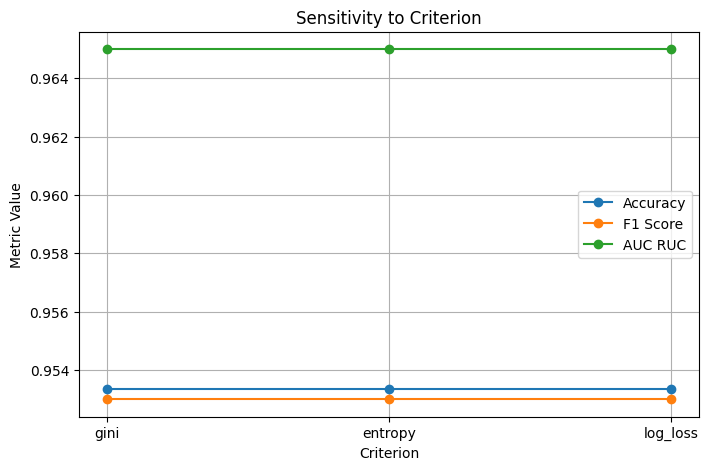

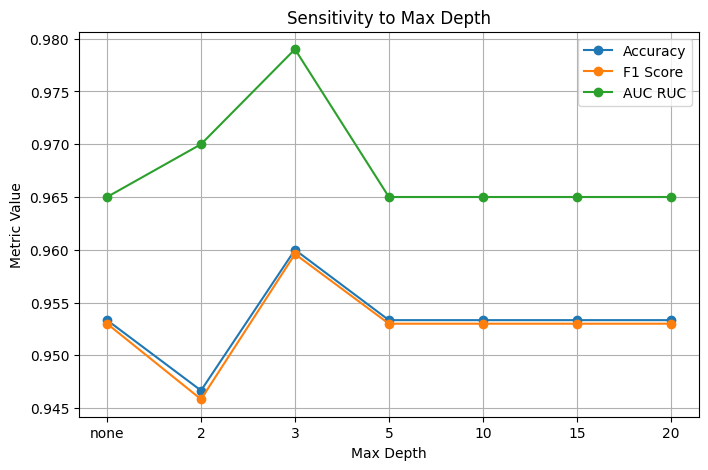

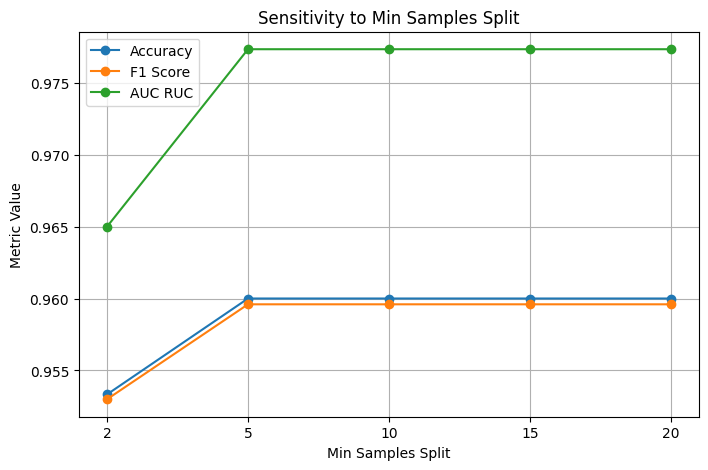

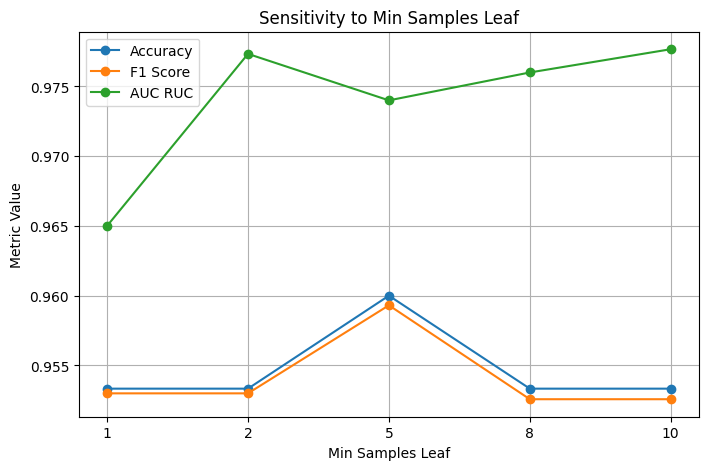

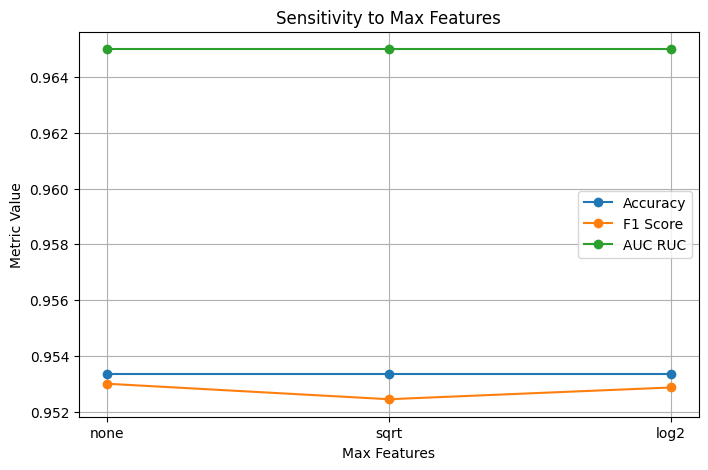

In [ ]:
plot_metrics(df_dt_criteria, "Criterion", "Sensitivity to Criterion")
plot_metrics(df_dt_maxdepth, "Max Depth", "Sensitivity to Max Depth")
plot_metrics(df_dt_minsamplesplit, "Min Samples Split", "Sensitivity to Min Samples Split")
plot_metrics(df_dt_minsamplesleaf, "Min Samples Leaf", "Sensitivity to Min Samples Leaf")
plot_metrics(df_dt_maxfeatures, "Max Features", "Sensitivity to Max Features")

# Support Vector Machine

In [ ]:
# defualt values for SVC in scikit

# class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False,
# tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr',
# break_ties=False, random_state=None)

In [ ]:
# defining all hyperparameter values
C_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
degree_for_poly = [2, 3, 4, 5]
gamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

In [ ]:
svm_C = []
for c in C_vals:
    model = SVC(C=c, probability=True)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    svm_C.append({'C': c,
                'Kernel' : 'rbf',
                'Degree' : 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

svm_kernel = []
for k in kernel:
    model = SVC(kernel=k, probability=True)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    svm_kernel.append({'C': 1.0,
                'Kernel': k,
                'Degree' : 3 if k == 'poly' else 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

svm_degree_for_poly = []
for d in degree_for_poly:
    model = SVC(kernel='poly', degree=d, probability=True)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    svm_degree_for_poly.append({'C': 1.0,
                'Kernel': 'poly',
                'Degree' : d,
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

svm_gamma = []
for g in gamma:
    model = SVC(gamma=g, probability=True)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    svm_gamma.append({'C': 1.0,
                'Kernel': 'rbf',
                'Degree' : 'None',
                'Gamma' : g,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

In [ ]:
df_svm_C = pd.DataFrame(svm_C)
df_svm_kernel = pd.DataFrame(svm_kernel)
df_svm_degree = pd.DataFrame(svm_degree_for_poly)
df_svm_gamma = pd.DataFrame(svm_gamma)

display(df_svm_C)
print("\n\n")
display(df_svm_kernel)
print("\n\n")
display(df_svm_degree)
print("\n\n")
display(df_svm_gamma)
print("\n\n")


svm_hp_cval_acc = (df_svm_C['Mean Accuracy'].var())
svm_hp_kern_acc = (df_svm_kernel['Mean Accuracy'].var())
svm_hp_degr_acc = (df_svm_degree['Mean Accuracy'].var())
svm_hp_gamm_acc = (df_svm_gamma['Mean Accuracy'].var())

svm_hp_cval_f1 = (df_svm_C['Mean F1 Score'].var())
svm_hp_kern_f1 = (df_svm_kernel['Mean F1 Score'].var())
svm_hp_degr_f1 = (df_svm_degree['Mean F1 Score'].var())
svm_hp_gamm_f1 = (df_svm_gamma['Mean F1 Score'].var())

svm_hp_cval_auc = (df_svm_C['Mean AUC ROC'].var())
svm_hp_kern_auc = (df_svm_kernel['Mean AUC ROC'].var())
svm_hp_degr_auc = (df_svm_degree['Mean AUC ROC'].var())
svm_hp_gamm_auc = (df_svm_gamma['Mean AUC ROC'].var())

print("C (Accuracy) : " + str(svm_hp_cval_acc))
print("Kernel (Accuracy) : " + str(svm_hp_kern_acc))
print("Degree for Poly Kernel (Accuracy) : " + str(svm_hp_degr_acc))
print("Gamma (Accuracy) : " + str(svm_hp_gamm_acc))
print("\n")
print("C (F1 Score) : " + str(svm_hp_cval_f1))
print("Kernel (F1 Score) : " + str(svm_hp_kern_f1))
print("Degree for Poly Kernel (F1 Score) : " + str(svm_hp_degr_f1))
print("Gamma (F1 Score) : " + str(svm_hp_gamm_f1))
print("\n")
print("C (AUC) : " + str(svm_hp_cval_auc))
print("Kernel (AUC) : " + str(svm_hp_kern_auc))
print("Degree for Poly Kernel (AUC) : " + str(svm_hp_degr_auc))
print("Gamma (AUC) : " + str(svm_hp_gamm_auc))
print("\n")

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,0.001,rbf,None,scale,0.900000,0.898973,0.189333
1,0.010,rbf,None,scale,0.900000,0.898973,0.580667
2,0.100,rbf,None,scale,0.920000,0.918485,0.988000
3,1.000,rbf,None,scale,0.966667,0.966465,0.997333
4,10.000,rbf,None,scale,0.966667,0.966465,0.997333
5,100.000,rbf,None,scale,0.946667,0.945842,0.993333
6,1000.000,rbf,None,scale,0.940000,0.939242,0.980667


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,linear,None,scale,0.966667,0.966044,0.997333
1,1.0,poly,3,scale,0.940000,0.938131,0.997333
2,1.0,rbf,None,scale,0.966667,0.966465,0.997333
3,1.0,sigmoid,None,scale,0.906667,0.900342,0.978000


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,poly,2,scale,0.873333,0.864582,0.955333
1,1.0,poly,3,scale,0.940000,0.938131,0.997333
2,1.0,poly,4,scale,0.813333,0.799331,0.954667
3,1.0,poly,5,scale,0.866667,0.859243,0.995333


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,rbf,None,scale,0.966667,0.966465,0.997333
1,1.0,rbf,None,auto,0.966667,0.966465,0.997333
2,1.0,rbf,None,0.001,0.860000,0.857441,0.819333
3,1.0,rbf,None,0.01,0.893333,0.892239,0.985333
4,1.0,rbf,None,0.1,0.980000,0.979933,0.997333
5,1.0,rbf,None,1,0.953333,0.952997,0.997333





C (Accuracy) : 0.0008063492063492055
Kernel (Accuracy) : 0.0008111111111111123
Degree for Poly Kernel (Accuracy) : 0.0026962962962962934
Gamma (Accuracy) : 0.0023422222222222186


C (F1 Score) : 0.0008280505066700347
Kernel (F1 Score) : 0.000974932133970938
Degree for Poly Kernel (F1 Score) : 0.0032311538078468737
Gamma (F1 Score) : 0.0024323284944469006


C (AUC) : 0.10032865608465608
Kernel (AUC) : 9.344444444444318e-05
Degree for Poly Kernel (AUC) : 0.0005702222222222223
Gamma (AUC) : 0.005162266666666663




In [ ]:
svm_summary = pd.DataFrame({
    "Hyperparameter": ["C Value","Kernel","Degree for Polynomial Kernel","Gamma"],
    "Var_Accuracy": [svm_hp_cval_acc, svm_hp_kern_acc, svm_hp_degr_acc, svm_hp_gamm_acc],
    "Var_F1_Score": [svm_hp_cval_f1, svm_hp_kern_f1, svm_hp_degr_f1, svm_hp_gamm_f1],
    "Var_AUC_ROC": [svm_hp_cval_auc, svm_hp_kern_auc, svm_hp_degr_auc, svm_hp_gamm_auc]
})

display(svm_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,C Value,0.000806,0.000828,0.100329
1,Kernel,0.000811,0.000975,0.000093
2,Degree for Polynomial Kernel,0.002696,0.003231,0.000570
3,Gamma,0.002342,0.002432,0.005162


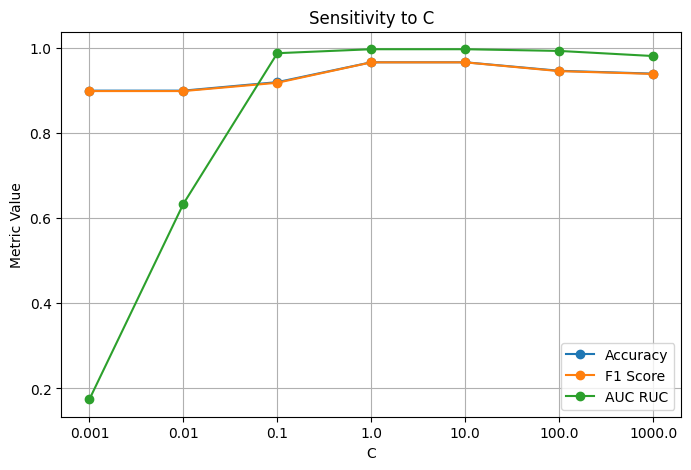

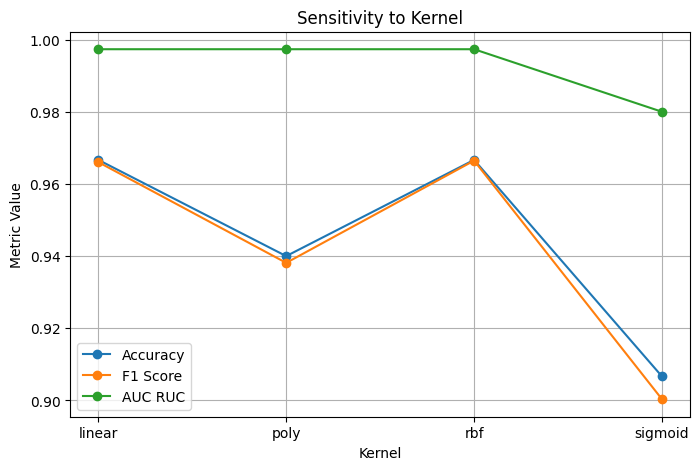

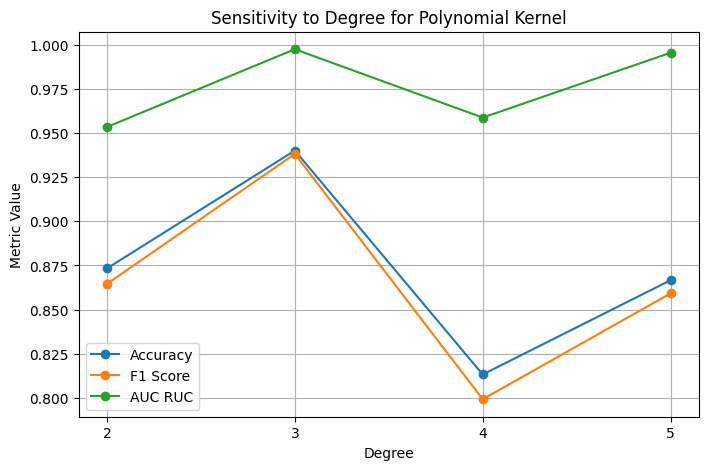

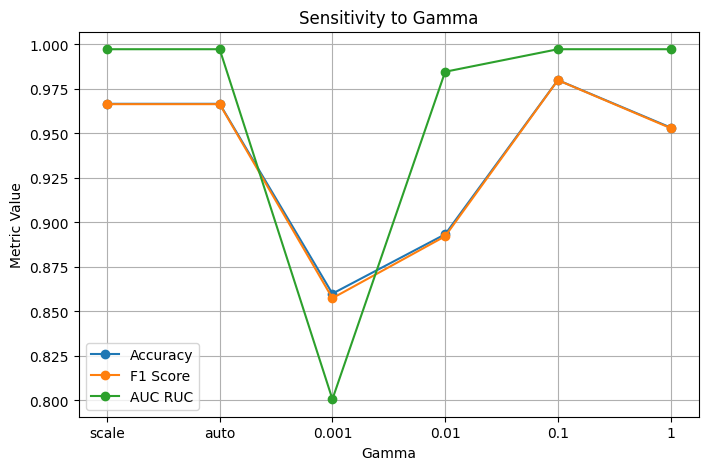

In [ ]:
plot_metrics(df_svm_C, "C", "Sensitivity to C")
plot_metrics(df_svm_kernel, "Kernel", "Sensitivity to Kernel")
plot_metrics(df_svm_degree, "Degree", "Sensitivity to Degree for Polynomial Kernel")
plot_metrics(df_svm_gamma, "Gamma", "Sensitivity to Gamma")

# Neural Networks (MLP)

In [ ]:
# defualt values for MLP in scikit

# class sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam',
# alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200,
# shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True,
# early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)

In [ ]:
# defining all hyperparameter values

hidden_layer_sizes = [(10,),(50,),(100,),(10, 10),(50, 50),(100, 50)]
activation = ['identity', 'logistic', 'tanh', 'relu']
alphas = [0.0001, 0.001, 0.01, 0.1,1, 10, 100, 1000]
learning_rate = ['constant', 'invscaling', 'adaptive'] # only if solver is sgd
learning_rate_init = [0.0001, 0.001, 0.01, 0.1]

# solvers = ['lbfgs','sgd','adam'] # ??

In [ ]:
mlp_hidden = []
for h in hidden_layer_sizes:
    # had to increase max_iter by A LOT and solver lbfgs is just faster for smaller datasets like iris
    model = MLPClassifier(hidden_layer_sizes=h, solver='lbfgs', max_iter=3000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    mlp_hidden.append({'Hidden Layer Sizes': h,
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

mlp_activation = []
for a in activation:
    model = MLPClassifier(activation=a, max_iter=3000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    mlp_activation.append({'Hidden Layer Sizes': (100,),
                'Activation' : a,
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

mlp_alphas = []
for a in alphas:
    model = MLPClassifier(alpha=a, max_iter=3000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    mlp_alphas.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : a,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

mlp_learning_rate = []
for l in learning_rate:
    model = MLPClassifier(learning_rate=l, solver='sgd', max_iter=3000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    mlp_learning_rate.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : l,
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

mlp_learning_rate_init = []
for l in learning_rate_init:
    model = MLPClassifier(learning_rate_init=l, max_iter=3000)
    scores = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1_macro', 'roc_auc_ovr'], n_jobs=-1)
    mlp_learning_rate_init.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : l,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score': scores['test_f1_macro'].mean(),
                'Mean AUC ROC': scores['test_roc_auc_ovr'].mean()})

In [ ]:
df_mlp_hidden = pd.DataFrame(mlp_hidden)
df_mlp_activation = pd.DataFrame(mlp_activation)
df_mlp_alpha = pd.DataFrame(mlp_alphas)
df_mlp_learning_rate = pd.DataFrame(mlp_learning_rate)
df_mlp_learning_rate_init = pd.DataFrame(mlp_learning_rate_init)

display(df_mlp_hidden)
print("\n\n")
display(df_mlp_activation)
print("\n\n")
display(df_mlp_alpha)
print("\n\n")
display(df_mlp_learning_rate)
print("\n\n")
display(df_mlp_learning_rate_init)
print("\n\n")


mlp_hp_hidd_acc = (df_mlp_hidden['Mean Accuracy'].var())
mlp_hp_acti_acc = (df_mlp_activation['Mean Accuracy'].var())
mlp_hp_alph_acc = (df_mlp_alpha['Mean Accuracy'].var())
mlp_hp_lear_acc = (df_mlp_learning_rate['Mean Accuracy'].var())
mlp_hp_inlr_acc = (df_mlp_learning_rate_init['Mean Accuracy'].var())

mlp_hp_hidd_f1 = (df_mlp_hidden['Mean F1 Score'].var())
mlp_hp_acti_f1 = (df_mlp_activation['Mean F1 Score'].var())
mlp_hp_alph_f1 = (df_mlp_alpha['Mean F1 Score'].var())
mlp_hp_lear_f1 = (df_mlp_learning_rate['Mean F1 Score'].var())
mlp_hp_inlr_f1 = (df_mlp_learning_rate_init['Mean F1 Score'].var())

mlp_hp_hidd_auc = (df_mlp_hidden['Mean AUC ROC'].var())
mlp_hp_acti_auc = (df_mlp_activation['Mean AUC ROC'].var())
mlp_hp_alph_auc = (df_mlp_alpha['Mean AUC ROC'].var())
mlp_hp_lear_auc = (df_mlp_learning_rate['Mean AUC ROC'].var())
mlp_hp_inlr_auc = (df_mlp_learning_rate_init['Mean AUC ROC'].var())

print("Hidden Layer Sizes (Accuracy) : " + str(mlp_hp_hidd_acc))
print("Activation Function (Accuracy) : " + str(mlp_hp_acti_acc))
print("Alpha (Accuracy) : " + str(mlp_hp_alph_acc))
print("Learning Rate (Accuracy) : " + str(mlp_hp_lear_acc))
print("Learning Rate Init (Accuracy) : " + str(mlp_hp_inlr_acc))
print("\n")
print("Hidden Layer Sizes (F1 Score) : " + str(mlp_hp_hidd_f1))
print("Activation Function (F1 Score) : " + str(mlp_hp_acti_f1))
print("Alpha (F1 Score) : " + str(mlp_hp_alph_f1))
print("Learning Rate (F1 Score) : " + str(mlp_hp_lear_f1))
print("Learning Rate Init (F1 Score) : " + str(mlp_hp_inlr_f1))
print("\n")
print("Hidden Layer Sizes (AUC) : " + str(mlp_hp_hidd_auc))
print("Activation Function (AUC) : " + str(mlp_hp_acti_auc))
print("Alpha (AUC) : " + str(mlp_hp_alph_auc))
print("Learning Rate (AUC) : " + str(mlp_hp_lear_auc))
print("Learning Rate Init (AUC) : " + str(mlp_hp_inlr_auc))

,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(10,)",relu,0.0001,constant,0.001,0.953333,0.952997,0.991333
1,"(50,)",relu,0.0001,constant,0.001,0.953333,0.952997,0.986333
2,"(100,)",relu,0.0001,constant,0.001,0.946667,0.946263,0.986667
3,"(10, 10)",relu,0.0001,constant,0.001,0.953333,0.952576,0.994333
4,"(50, 50)",relu,0.0001,constant,0.001,0.946667,0.945842,0.986333
5,"(100, 50)",relu,0.0001,constant,0.001,0.946667,0.946263,0.984667


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",identity,0.0001,constant,0.001,0.973333,0.973199,0.997333
1,"(100,)",logistic,0.0001,constant,0.001,0.966667,0.966465,0.997333
2,"(100,)",tanh,0.0001,constant,0.001,0.973333,0.973199,0.997333
3,"(100,)",relu,0.0001,constant,0.001,0.960000,0.959731,0.997333


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.973333,0.973199,0.997333
1,"(100,)",relu,0.0010,constant,0.001,0.973333,0.973199,0.997333
2,"(100,)",relu,0.0100,constant,0.001,0.966667,0.966465,0.997333
3,"(100,)",relu,0.1000,constant,0.001,0.960000,0.959731,0.997333
4,"(100,)",relu,1.0000,constant,0.001,0.973333,0.973199,0.997333
5,"(100,)",relu,10.0000,constant,0.001,0.946667,0.946128,0.993333
6,"(100,)",relu,100.0000,constant,0.001,0.733333,0.674281,0.833333
7,"(100,)",relu,1000.0000,constant,0.001,0.500000,0.360077,0.880000


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.946667,0.946128,0.996000
1,"(100,)",relu,0.0001,invscaling,0.001,0.413333,0.299913,0.699333
2,"(100,)",relu,0.0001,adaptive,0.001,0.946667,0.946128,0.996000


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.0001,0.953333,0.952862,0.997333
1,"(100,)",relu,0.0001,constant,0.0010,0.966667,0.966465,0.997333
2,"(100,)",relu,0.0001,constant,0.0100,0.960000,0.959731,0.996000
3,"(100,)",relu,0.0001,constant,0.1000,0.953333,0.952997,0.996000





Hidden Layer Sizes (Accuracy) : 1.3333333333333504e-05
Activation Function (Accuracy) : 4.0740740740741145e-05
Alpha (Accuracy) : 0.030053968253968253
Learning Rate (Accuracy) : 0.09481481481481484
Learning Rate Init (Accuracy) : 4.0740740740741145e-05


Hidden Layer Sizes (F1 Score) : 1.3651290306733505e-05
Activation Function (F1 Score) : 4.156794280251033e-05
Alpha (F1 Score) : 0.05017063948180979
Learning Rate (F1 Score) : 0.13919779039768562
Learning Rate Init (F1 Score) : 4.202594595411642e-05


Hidden Layer Sizes (AUC) : 1.3840740740740586e-05
Activation Function (AUC) : 0.0
Alpha (AUC) : 0.004357460317460317
Learning Rate (AUC) : 0.029337037037037075
Learning Rate Init (AUC) : 5.92592592592462e-07


In [ ]:
mlp_summary = pd.DataFrame({
    "Hyperparameter": ["Hidden Layers Size", "Activation Function", "Alpha", "Learning Rate", "Learning Rate Initial"],
    "Var_Accuracy": [mlp_hp_hidd_acc, mlp_hp_acti_acc, mlp_hp_alph_acc, mlp_hp_lear_acc, mlp_hp_inlr_acc],
    "Var_F1_Score": [mlp_hp_hidd_f1, mlp_hp_acti_f1, mlp_hp_alph_f1, mlp_hp_lear_f1, mlp_hp_inlr_f1],
    "Var_AUC_ROC": [mlp_hp_hidd_acc, mlp_hp_acti_auc, mlp_hp_alph_auc, mlp_hp_lear_auc, mlp_hp_inlr_auc]
})

display(mlp_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Hidden Layers Size,0.000013,0.000014,1.333333e-05
1,Activation Function,0.000041,0.000042,0.000000e+00
2,Alpha,0.030054,0.050171,4.357460e-03
3,Learning Rate,0.094815,0.139198,2.933704e-02
4,Learning Rate Initial,0.000041,0.000042,5.925926e-07


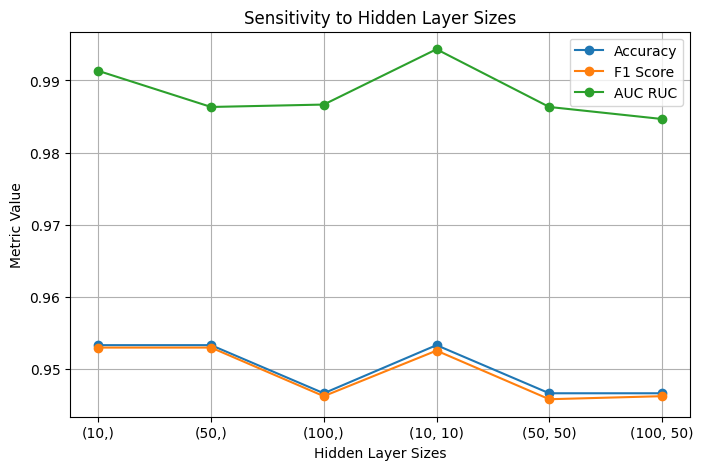

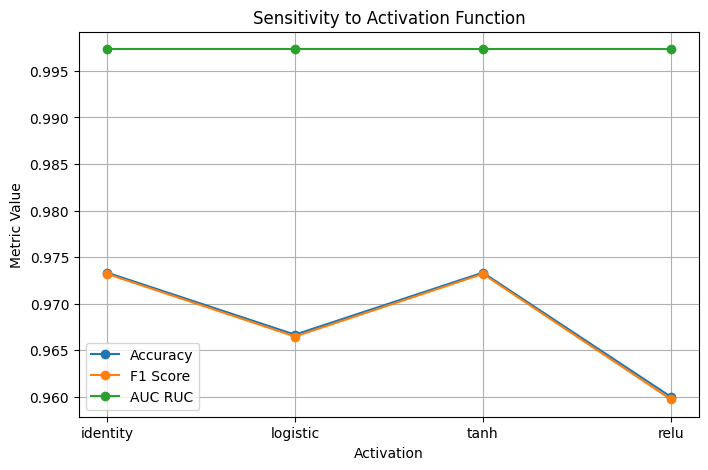

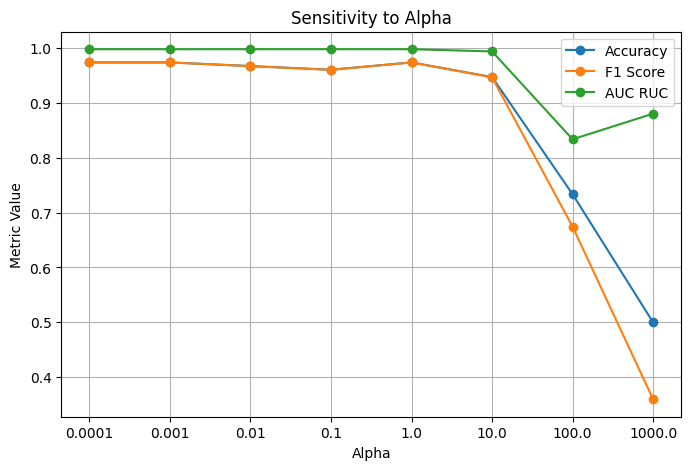

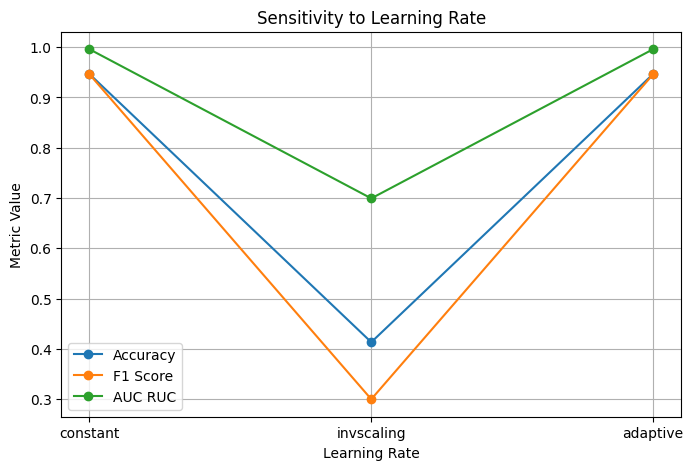

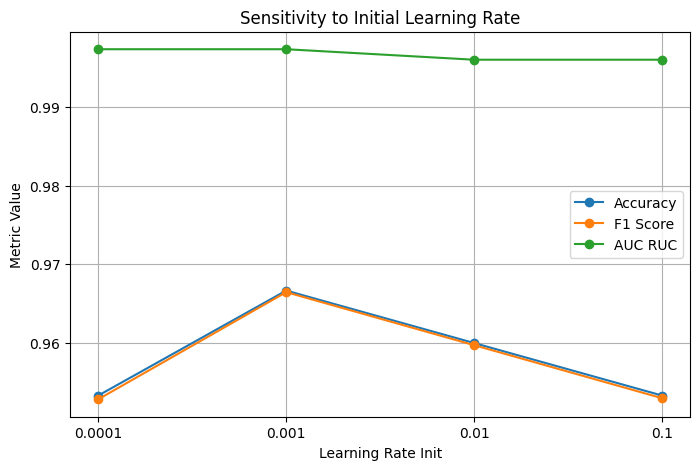

In [ ]:
plot_metrics(df_mlp_hidden, "Hidden Layer Sizes", "Sensitivity to Hidden Layer Sizes")
plot_metrics(df_mlp_activation, "Activation", "Sensitivity to Activation Function")
plot_metrics(df_mlp_alpha, "Alpha", "Sensitivity to Alpha")
plot_metrics(df_mlp_learning_rate, "Learning Rate", "Sensitivity to Learning Rate")
plot_metrics(df_mlp_learning_rate_init, "Learning Rate Init", "Sensitivity to Initial Learning Rate")